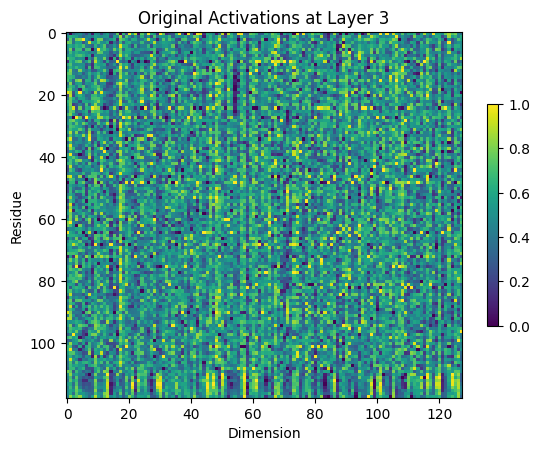

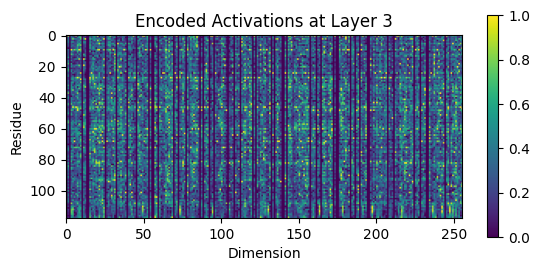

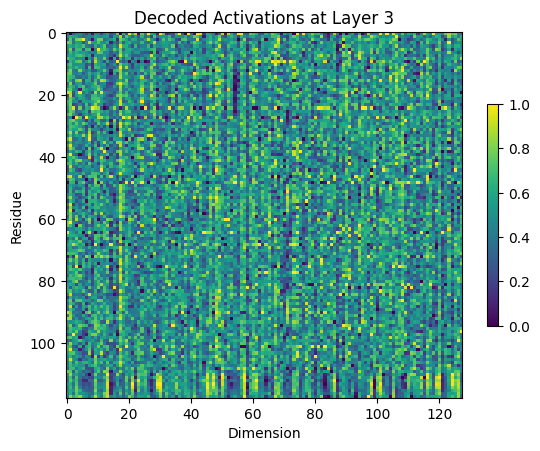

In [15]:
import importlib
import numpy as np
import torch
import copy
import random
import matplotlib.pyplot as plt
from mdl_utils import make_graphs, tied_featurize, parse_PDB, create_labels
from mdl_utils import StructureDataset, StructureDatasetPDB, EncoderProteinMPNN, DecoderProteinMPNN, run_dssp
import pandas as pd
#importlib.reload(mdl_utils)
#import Bio.PDB
from Bio.PDB import PDBParser, DSSP, PPBuilder
import pandas as pd
#importlib.reload(Bio.PDB)
seed = 0
path_to_node_model_weights = "../training/exp_020/model_weights/node_log18_NM"
model_name = 'epoch_last'
out_folder = "../evaluation/outputs/training_test_output"
num_seq_per_target = 1
batch_size = 1
sampling_temp = "0.1"
#pdb_path = "/WAVE/bio/MD/senior_design_neelm/scfv_native/scfv_native.pdb"
pdb_path = "1cewunsttail.pdb"
max_length = 200000
backbone_noise = 0.00
show_graphs = True
SAE_level = "node"
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)   

hidden_dim = 128
num_layers = 3 

model_folder_path = path_to_node_model_weights
if model_folder_path[-1] != '/':
    model_folder_path = model_folder_path + '/'

checkpoint_path = model_folder_path + f'{model_name}.pt'

BATCH_COPIES = batch_size
alphabet = 'ACDEFGHIKLMNPQRSTVWYX'   
device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")

pdb_dict_list = parse_PDB(pdb_path, ca_only=False)
dataset_valid = StructureDatasetPDB(pdb_dict_list, truncate=None, max_length=max_length)

basic_checkpoint_path = "../training/exp_020/v_48_020.pt"
#checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
checkpoint = torch.load(basic_checkpoint_path, map_location=device, weights_only=False)
node_checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

# Infer expansion size of latent space
size = int(node_checkpoint['model_state_dict']['sae_layers.0.WS1.weight'].shape[0] / 128)
encoder_model = EncoderProteinMPNN(num_letters=21,
                    node_features=hidden_dim,
                    edge_features=hidden_dim, 
                    hidden_dim=hidden_dim,
                    expansion=size,
                    num_encoder_layers=num_layers, 
                    num_decoder_layers=num_layers, 
                    augment_eps=backbone_noise, 
                    k_neighbors=checkpoint['num_edges'])
encoder_model.to(device)    

encoder_model.load_state_dict(checkpoint['model_state_dict'], strict=False)


filtered_node_state_dict = {}
for k, v in node_checkpoint['model_state_dict'].items():
    if 'sae_layers' in k:
      k = k[11:]
      filtered_node_state_dict[k] = v
encoder_model.node_sae_layers.load_state_dict(filtered_node_state_dict, strict=True)


edge_checkpoint_path = "../training/exp_020/model_weights/edge_log15_KI/epoch_last.pt"
edge_checkpoint = torch.load(edge_checkpoint_path, map_location=device, weights_only=False)

filtered_state_dict = {}
for k, v in edge_checkpoint['model_state_dict'].items():
    if 'sae_layers' in k:
      k = k[11:]
      filtered_state_dict[k] = v
encoder_model.edge_sae_layers.load_state_dict(filtered_state_dict, strict=True)

encoder_model.eval()

decoder_model = DecoderProteinMPNN(num_letters=21,
                    node_features=hidden_dim,
                    edge_features=hidden_dim, 
                    hidden_dim=hidden_dim,
                    expansion=size,
                    num_encoder_layers=num_layers, 
                    num_decoder_layers=num_layers, 
                    augment_eps=backbone_noise, 
                    k_neighbors=48)
decoder_model.to(device)    
#basic_checkpoint_path = "../training/exp_020/v_48_020.pt"
basic_checkpoint = torch.load(basic_checkpoint_path, map_location=device, weights_only=False)
decoder_model.load_state_dict(basic_checkpoint['model_state_dict'], strict=False)

decoder_model.eval();
with torch.no_grad():
    for ix, protein in enumerate(dataset_valid):
        batch_clones = [copy.deepcopy(protein) for i in range(BATCH_COPIES)]
        X, S, mask,_, chain_M, chain_encoding_all,_,_,_,_, chain_M_pos,_, residue_idx,_,_,_,_,_,_,_ = tied_featurize(batch_clones, device, chain_dict=None)
        if SAE_level == 'node':
            error, res_labels = create_labels(pdb_path, SAE_level)
            if error != True:
                randn_1 = torch.randn(chain_M.shape, device=device)
                h_V, h_E, n_original, n_encoded, n_decoded, E_idx, e_original, e_encoded, e_decoded = encoder_model(X, mask, residue_idx, chain_encoding_all)
            
if show_graphs:
    model_name = '/'.join(path_to_node_model_weights.split('/')[-1:])
    protein_name = pdb_path[-8:-4]
    layer = 2
    graph_info = [model_name, protein_name, layer, 'Node']
    make_graphs(n_original, "Original", 2, graph_info)
    make_graphs(n_encoded, "Encoded", 2, graph_info)
    make_graphs(n_decoded, "Decoded", 2, graph_info)

In [16]:
mask_for_empty = np.asarray((S[0] != 20).cpu())
node_encoded = np.round(encoder_model.node_encoded_act[2].cpu().numpy()[0,:,:], decimals=5)[mask_for_empty] # (N, 256)
edge_encoded = np.round(encoder_model.edge_encoded_act[2].cpu().numpy()[0,:,:,:], decimals=5)[mask_for_empty] # (N, 48, 256)


edge_encoded_ = torch.tensor(np.reshape(edge_encoded, (1, -1, 48, 256)))
W2_edge = encoder_model.edge_sae_layers[2].WS2.weight
b2_edge = encoder_model.edge_sae_layers[2].WS2.bias
W1_edge = encoder_model.edge_sae_layers[2].WS1.weight
b1_edge = encoder_model.edge_sae_layers[2].WS1.bias
W1_edge_pinv = torch.linalg.pinv(W1_edge)

edge_encoded_ = edge_encoded_.to(W2_edge.dtype)
edge_encoded_ = edge_encoded_ @ W2_edge.T + b2_edge

node_encoded_ = torch.tensor(np.reshape(node_encoded, (1, -1, 256)))

W2_node = encoder_model.node_sae_layers[2].WS2.weight
b2_node = encoder_model.node_sae_layers[2].WS2.bias
W1_node = encoder_model.node_sae_layers[2].WS1.weight
b1_node = encoder_model.node_sae_layers[2].WS1.bias
W2_node_pinv = torch.linalg.pinv(W1_node)

node_encoded_ = node_encoded_.to(W2_node.dtype)
node_encoded_ = node_encoded_ @ W2_node.T + b2_node

In [17]:
change = 10

In [18]:
for i in range(110, 118):
    node_encoded[i, 99] += change # 0.185 
    node_encoded[i, 79] += change # 0.842 ROC
    node_encoded[i, 254] -= change # 0.229 ROC
    edge_encoded[i, :5, :] = edge_encoded[i-95, :5, :] # Same edges as other a helix

edge_modified = torch.tensor(np.reshape(edge_encoded, (1, -1, 48, 256)))
edge_modified = edge_modified.to(W2_edge.dtype)
edge_modified = edge_modified @ W2_edge.T + b2_edge


node_modified = torch.tensor(np.reshape(node_encoded, (1, -1, 256)))
node_modified = node_modified.to(W2_node.dtype)
node_modified = node_modified @ W2_node.T + b2_node


with torch.no_grad():
    for ix, protein in enumerate(dataset_valid):
        batch_clones = [copy.deepcopy(protein) for i in range(BATCH_COPIES)]
        randn_1 = torch.randn(chain_M.shape, device=device)
        log_probs = decoder_model(X, S, mask, chain_M*chain_M_pos, h_V, h_E, E_idx, randn_1)

    S_new = torch.argmax(log_probs, dim=2)
    alphabet = 'ACDEFGHIKLMNPQRSTVWYX'
    seq = ''.join([alphabet[c] for c in S_new[0]])
    print(f"Original\nWith SAE\nModified\n{seq}")
    for ix, protein in enumerate(dataset_valid):
        batch_clones = [copy.deepcopy(protein) for i in range(BATCH_COPIES)]
        randn_1 = torch.randn(chain_M.shape, device=device)
        log_probs = decoder_model(X, S, mask, chain_M*chain_M_pos, node_encoded_, edge_encoded_, E_idx, randn_1)

    S_new = torch.argmax(log_probs, dim=2)
    alphabet = 'ACDEFGHIKLMNPQRSTVWYX'
    seq = ''.join([alphabet[c] for c in S_new[0]])
    print(f"{seq}")

    for ix, protein in enumerate(dataset_valid):
        batch_clones = [copy.deepcopy(protein) for i in range(BATCH_COPIES)]
        randn_1 = torch.randn(chain_M.shape, device=device)
        log_probs = decoder_model(X, S, mask, chain_M*chain_M_pos, node_modified, edge_modified, E_idx, randn_1)

    S_new = torch.argmax(log_probs, dim=2)
    alphabet = 'ACDEFGHIKLMNPQRSTVWYX'
    seq = ''.join([alphabet[c] for c in S_new[0]])
    print(f"{seq}")


Original
With SAE
Modified
SEPVDVAFSDPLLQKALEYAIDEYNKKSKDEYAYKVVKILEAEVQEGDGLVYHITVEIARTKCPKSEPDIESCPFFPDPEKAEFRTCEFVVYEKPEKNEIELLEKECEGLSKKSSSLS
GPPVDVAESDPLFQKSLDYALEEYNKKSDDEYAYKVVRILSAEKKRGDGLVYYITVEIGRTTCPKSDPDVESCPLFPDPEKANPRTCEFVVFEKPSKNEIEVEEIECEGLSEESESSP
SPPVPVDEDDPELQEALDYAIEEYNKKSSDKYAYKVKRILSAEVQEGDGLVYYLTVEIGRTKCPKSEPDVESCPFFPDPELALLRLCTFVVEEVPEKNEEEVLELKCEGLIIMMMLII
